# Isolation Forest Model for Anamoly Detection on CICIDS 17

## Importing Libraries and Creating Dataframes

In [152]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [23]:
mon = pd.read_csv("C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Monday-WorkingHours.pcap_ISCX.csv")
mon.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [27]:
tue = pd.read_csv("C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Tuesday-WorkingHours.pcap_ISCX.csv")
tue.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
print(*mon.columns, sep='\n')


 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Header Length.1
Fwd Avg

In [ ]:
mon.shape

(529918, 79)

In [28]:
tue.shape

(445909, 79)

79 Features, 5,29,918 flows of benign traffic

79 Features,4,45,909 flows of attack + Benign Traffic on Tue 

In [ ]:
mon.dtypes

 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                          object
Length: 79, dtype: object

In [ ]:
mon.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,529918.000000,5.299180e+05,529918.000000,529918.000000,5.299180e+05,5.299180e+05,529918.000000,529918.000000,529918.000000,529918.000000,...,529918.000000,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05
mean,10644.367112,1.038927e+07,10.390315,11.517105,5.324195e+02,1.789841e+04,190.897188,20.277279,50.744078,57.452269,...,7.412509,-3.614576e+03,6.843482e+04,4.321930e+04,1.453907e+05,4.380369e+04,3.463918e+06,2.024408e+05,3.620657e+06,3.274066e+06
std,21390.213475,2.875195e+07,892.412791,1173.318788,6.228642e+03,2.675470e+06,448.833754,36.275793,91.964713,146.518081,...,851.762351,5.526328e+05,5.872322e+05,3.971455e+05,1.028606e+06,4.993677e+05,1.297057e+07,2.170149e+06,1.340649e+07,1.273216e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.760000e+02,2.000000,1.000000,1.800000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.130300e+04,2.000000,2.000000,6.800000e+01,1.440000e+02,40.000000,6.000000,38.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.557448e+05,4.000000,3.000000,1.870000e+02,3.920000e+02,83.000000,40.000000,53.000000,26.162951,...,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65535.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,23360.000000,2293.000000,4638.923469,7125.596846,...,213557.000000,1.260000e+02,1.016597e+08,6.434950e+07,1.016597e+08,1.016597e+08,1.199997e+08,7.514502e+07,1.199997e+08,1.199997e+08


## Some Cleaning Steps need to be taken:

- Some features having leading spaces; Might cause erros when looking at that column later; so strip them
- inf values present in some columns 
- Fwd Header legnth.1 is a repeated feature
- Some have zero variance which will be removed before training
 

In [29]:
mon.columns = mon.columns.str.strip()
tue.columns = tue.columns.str.strip()

In [30]:
mon.replace([np.inf, -np.inf], np.nan, inplace=True)
tue.replace([np.inf, -np.inf], np.nan, inplace=True)

mon.dropna(inplace=True)
tue.dropna(inplace=True)

In [31]:
print(mon.shape)
print(tue.shape)

(529481, 79)
(445645, 79)


In [32]:
y_mon = mon['Label']
X_mon = mon.drop(columns=['Label'])

y_tue = tue['Label']
X_tue = tue.drop(columns=['Label'])

In [33]:
X_mon = X_mon.drop(columns=['Fwd Header Length.1'])
X_tue = X_tue.drop(columns=['Fwd Header Length.1'])

In [34]:
zero_features = [
'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate'
]

X_mon = X_mon.drop(columns=zero_features)
X_tue = X_tue.drop(columns=zero_features)

In [ ]:
print(mon.shape)
print(tue.shape)

y_tue

(529481, 79)
(445645, 79)


### Feature Scaling 

In [ ]:
scaler = StandardScaler()

X_mon_scaled = scaler.fit_transform(X_mon)
X_tue_scaled = scaler.transform(X_tue)

In [61]:
X_mon_scaled.shape

(529481, 71)

## Training the model

In [75]:
model = IsolationForest(
    n_estimators=500,
    contamination=0.03,
    random_state=42,
    max_samples = 512
)
model.fit(X_mon_scaled)

IsolationForest(contamination=0.03, max_samples=512, n_estimators=500,
                random_state=42)

In [76]:
pred = model.predict(X_tue_scaled)

In [77]:
from collections import Counter
counts = Counter(pred)

print(f"Results: {counts}")
print(f"Normal points detected: {counts[1]}")
print(f"Anomalies detected: {counts[-1]}")

Results: Counter({1: 431537, -1: 14108})
Normal points detected: 431537
Anomalies detected: 14108


In [78]:
y_true = (y_tue != "BENIGN").astype(int)
y_pred = (pred == -1).astype(int)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97    431813
           1       0.00      0.00      0.00     13832

    accuracy                           0.94    445645
   macro avg       0.48      0.48      0.48    445645
weighted avg       0.94      0.94      0.94    445645



In [79]:
counts = Counter(y_pred)

print(f"Results: {counts}")
print(f"Normal points detected: {counts[0]}")
print(f"Anomalies detected: {counts[1]}")

Results: Counter({0: 431537, 1: 14108})
Normal points detected: 431537
Anomalies detected: 14108


Really poor Detection. The model is making a flase positives and not detecting atleast one anamoly correctly.

I feel like the containation and predict function are causing issue let's look at raw_scores and classify anamolies.


In [91]:
scores = model.decision_function(X_tue_scaled)
from sklearn.metrics import roc_auc_score

roc_auc_score(y_true, -scores)

0.6962868630676955

Not a really bad detection. Let's actually try some different parameters after checking why predictions went wrong.

In [90]:
scaled_df = pd.DataFrame(
    X_mon_scaled, 
    columns=X_mon.columns, 
    index=mon.index
)
scaled_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,...,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05,5.294810e+05
mean,3.929261e-17,2.233023e-17,-1.811647e-18,-1.435898e-18,-1.137983e-17,-2.012941e-19,-2.490679e-17,8.588549e-19,-1.404228e-16,1.580293e-16,...,1.113827e-18,6.441412e-19,3.757490e-17,-1.653296e-17,8.588549e-18,1.975366e-17,-5.024301e-17,2.640979e-17,4.981358e-17,-1.803595e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.972270e-01,-3.615103e-01,-1.052627e-02,-9.819553e-03,-8.551293e-02,-6.692584e-03,-4.255024e-01,-5.591306e-01,-5.519867e-01,-3.922809e-01,...,-8.705806e-03,-1.517231e+02,-1.165868e-01,-1.088704e-01,-1.414069e-01,-8.775485e-02,-2.671782e-01,-9.332319e-02,-2.701873e-01,-2.572628e-01
25%,-4.947481e-01,-3.615042e-01,-9.406171e-03,-8.967620e-03,-8.262423e-02,-6.692584e-03,-4.121390e-01,-5.591306e-01,-4.867646e-01,-3.922809e-01,...,-8.705806e-03,6.579562e-03,-1.165868e-01,-1.088704e-01,-1.414069e-01,-8.775485e-02,-2.671782e-01,-9.332319e-02,-2.701873e-01,-2.572628e-01
50%,-4.934853e-01,-3.604216e-01,-9.406171e-03,-8.115687e-03,-7.460008e-02,-6.638784e-03,-3.364131e-01,-3.937854e-01,-1.389132e-01,-3.922809e-01,...,-7.532253e-03,6.601268e-03,-1.165868e-01,-1.088704e-01,-1.414069e-01,-8.775485e-02,-2.671782e-01,-9.332319e-02,-2.701873e-01,-2.572628e-01
75%,-4.765069e-01,-3.490958e-01,-7.165978e-03,-7.263755e-03,-5.550260e-02,-6.546128e-03,-2.406422e-01,5.431701e-01,2.414207e-02,-2.137783e-01,...,-5.185146e-03,6.601268e-03,-1.165868e-01,-1.088704e-01,-1.414069e-01,-8.775485e-02,-2.671782e-01,-9.332319e-02,-2.701873e-01,-2.572628e-01
max,2.567993e+00,3.810626e+00,2.461397e+02,2.486881e+02,2.122942e+02,2.448787e+02,5.160262e+01,6.263026e+01,4.987476e+01,4.822369e+01,...,2.506118e+02,6.771293e-03,1.729298e+02,1.618553e+02,9.865122e+01,2.034059e+02,8.980982e+00,3.451922e+01,8.677268e+00,9.164051e+00


What could have gone wrong: -

- High dimensionality might be causing it some issues. Let's do feature selection for this.

- The way of training it. Training only on benign and expecting it to classify anamolous data might be wrong way to do it.Let's try making a random subset of 10,00,000 rows and 2,00,000 validation and 2,00,000 testing and try it out.

First let's try for some different model parameters using the decision function and then let's do the above steps one by one


In [110]:
model2 = IsolationForest(
    n_estimators=1000,
    contamination=0.01,
    random_state=42,
    max_samples = 512
)
model2.fit(X_mon_scaled)

IsolationForest(contamination=0.01, max_samples=512, n_estimators=1000,
                random_state=42)

In [111]:
scores = model2.decision_function(X_tue_scaled)

roc_auc_score(y_true, -scores)

0.6910862804406194

Little to no improvement in changing the hyperparameters

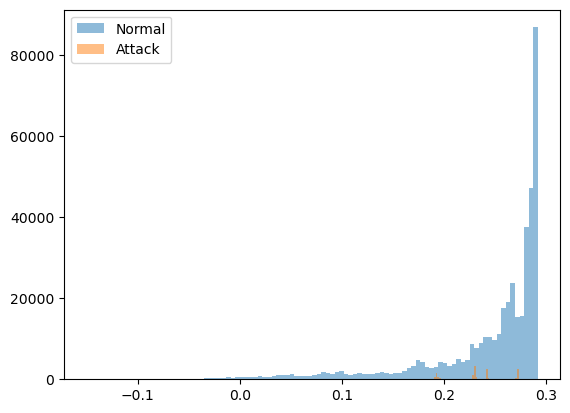

In [112]:
import matplotlib.pyplot as plt

plt.hist(scores[y_true==0], bins=100, alpha=0.5, label="Normal")
plt.hist(scores[y_true==1], bins=100, alpha=0.5, label="Attack")

plt.legend()
plt.show()

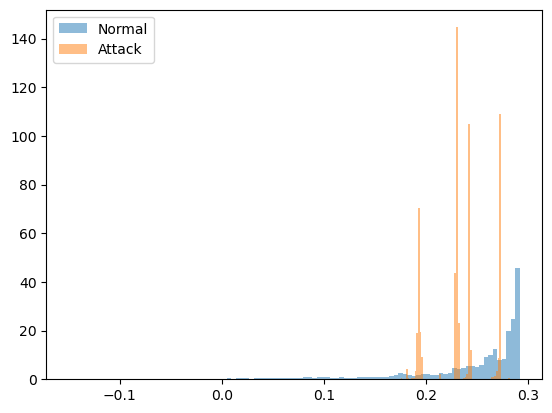

In [115]:
plt.hist(scores[y_true==0], bins=100, density=True, alpha=0.5, label="Normal")
plt.hist(scores[y_true==1], bins=100, density=True, alpha=0.5, label="Attack")
plt.legend()
plt.show()

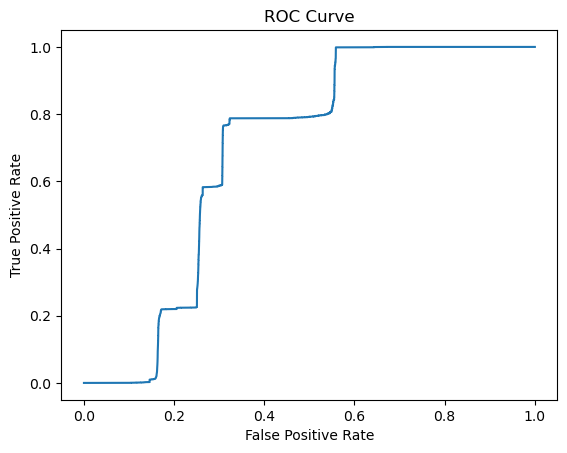

In [113]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, -scores)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
scores_tue = -model.decision_function(X_tue_scaled) 
fpr, tpr, thresholds = roc_curve(y_true, scores_tue)

# Calculate Youden's J statistic to find the optimal threshold
# J = Sensitivity + Specificity - 1, which translates to TPR - FPR
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Anomaly Threshold: {optimal_threshold}")

# Classify based on the new mathematical threshold
custom_predictions = (scores_tue >= optimal_threshold).astype(int)

print(classification_report(y_true, custom_predictions))

Optimal Anomaly Threshold: -0.18640550930107713
              precision    recall  f1-score   support

           0       0.99      0.68      0.81    431813
           1       0.07      0.79      0.13     13832

    accuracy                           0.69    445645
   macro avg       0.53      0.73      0.47    445645
weighted avg       0.96      0.69      0.79    445645



In [174]:
print(confusion_matrix(y_true,custom_predictions))

[[294900 136913]
 [  2948  10884]]


High False Alarms model is predicting almost everything as a attack but only few are correct

## Let's Improve using feature selection and dimensionality reduction

In [119]:
X_mon.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


In [123]:
X_mon.skew()

Destination Port                 1.619171
Flow Duration                    2.918228
Total Fwd Packets              224.852953
Total Backward Packets         226.051371
Total Length of Fwd Packets    149.469068
                                  ...    
Active Min                      50.966088
Idle Mean                        5.221992
Idle Std                        15.229505
Idle Max                         5.012089
Idle Min                         5.456768
Length: 71, dtype: float64

Looks like there is some Skewness present in almost all the fetaures. So our Preprocessing pipline now:-
- Reduce the skewness
- Standard Scaling
- PCA to get 95% variance

Then train isolation forest on this

In [130]:
def transform_features(df, mild_threshold=0.5, high_threshold=1.0):
    """
    Mild skew   (0.5 - 1.0):  sqrt transformation (gentler)
    High skew   (1.0 - 2.0):  log1p transformation (moderate)
    Extreme skew (> 2.0):     Box-Cox or Yeo-Johnson (most powerful)
    """
    df_transformed = df.copy()
    transformation_log = {}
    
    for col in df.columns:
        skewness = df[col].skew()
        abs_skew = abs(skewness)
        direction = 1 if skewness > 0 else -1
    
        if abs_skew <= mild_threshold:
            # Symmetric enough, skip
            transformation_log[col] = ('none', skewness)
            
        elif abs_skew <= high_threshold:
            # Mild skew → square root
            if direction == 1: 
                shift = abs(df[col].min()) + 1 if df[col].min() < 0 else 0
                df_transformed[col] = np.sqrt(df[col] + shift)
                transformation_log[col] = (f'sqrt(x + {shift:.2f})', skewness)
            else:
                reflected = df[col].max() + 1 - df[col]
                df_transformed[col] = -np.sqrt(reflected)
                transformation_log[col] = ('reflected_sqrt', skewness)
                
        elif abs_skew <= 2.0:
            # High skew → log1p
            if direction == 1:
                shift = abs(df[col].min()) + 1 if df[col].min() < 0 else 0
                df_transformed[col] = np.log1p(df[col] + shift)
                transformation_log[col] = (f'log1p(x + {shift:.2f})', skewness)
            else: 
                reflected = df[col].max() + 1 - df[col]
                df_transformed[col] = -np.log1p(reflected)
                transformation_log[col] = ('reflected_log1p', skewness)
                
        else:
            transformed, lambda_ = stats.yeojohnson(df[col])
            df_transformed[col] = transformed
            transformation_log[col] = (f'yeojohnson(λ={lambda_:.2f})', skewness)

    log_df = pd.DataFrame.from_dict(
        transformation_log,
        orient='index',
        columns=['transformation', 'original_skew']
    )
    log_df['new_skew'] = [df_transformed[col].skew() for col in log_df.index]
    log_df['improved'] = abs(log_df['new_skew']) < abs(log_df['original_skew'])
    
    return df_transformed, log_df

X_mon_tr, summary1 = transform_features(X_mon)
X_tue_tr,summary2 = transform_features(X_tue)
summary1

,transformation,original_skew,new_skew,improved
Destination Port,log1p(x + 0.00),1.619171,1.103151,True
Flow Duration,yeojohnson(λ=-0.01),2.918228,0.018704,True
Total Fwd Packets,yeojohnson(λ=-0.97),224.852953,0.331479,True
Total Backward Packets,yeojohnson(λ=-0.47),226.051371,0.050449,True
Total Length of Fwd Packets,yeojohnson(λ=0.03),149.469068,-0.002044,True
...,...,...,...,...
Active Min,yeojohnson(λ=-0.63),50.966088,2.050166,True
Idle Mean,yeojohnson(λ=-0.42),5.221992,2.032880,True
Idle Std,yeojohnson(λ=-1.04),15.229505,3.022578,True
Idle Max,yeojohnson(λ=-0.42),5.012089,2.032880,True


In [131]:
summary = pd.DataFrame({
    'original_skew': X_mon.skew(),
    'new_skew': X_mon_tr.skew()
}).round(4)

summary

,original_skew,new_skew
Destination Port,1.6192,1.1032
Flow Duration,2.9182,0.0187
Total Fwd Packets,224.8530,0.3315
Total Backward Packets,226.0514,0.0504
Total Length of Fwd Packets,149.4691,-0.0020
...,...,...
Active Min,50.9661,2.0502
Idle Mean,5.2220,2.0329
Idle Std,15.2295,3.0226
Idle Max,5.0121,2.0329


In [133]:
comparision2 = pd.DataFrame({
    'original_skew': X_tue.skew(),
    'new_skew': X_tue_tr.skew()
}).round(4)

comparision2

,original_skew,new_skew
Destination Port,1.8844,1.2467
Flow Duration,2.8821,0.0284
Total Fwd Packets,187.1194,0.3661
Total Backward Packets,186.3902,0.0775
Total Length of Fwd Packets,212.7364,-0.0218
...,...,...
Active Min,62.0905,2.0256
Idle Mean,5.4183,2.0203
Idle Std,19.2905,2.9103
Idle Max,5.2677,2.0203


We were able to reduce most of the skewness but it still exists. Now let's so standardisation

In [134]:
scaler = StandardScaler()

X_mon_scaled = scaler.fit_transform(X_mon_tr)
X_tue_scaled = scaler.transform(X_tue_tr)

Now selecting the features with variance greater than 0.01 prefiltering for PCA

In [138]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)

X_mon_var = selector.fit_transform(X_mon_scaled)
X_tue_var = selector.transform(X_tue_scaled)

variances = pd.Series(selector.variances_, index=X_mon.columns)
variances.sort_values().head(20)

Bwd PSH Flags             0.0
Bwd URG Flags             0.0
CWE Flag Count            0.0
Fwd URG Flags             0.0
ECE Flag Count            1.0
Bwd Header Length         1.0
Flow Bytes/s              1.0
Down/Up Ratio             1.0
ACK Flag Count            1.0
Bwd Packet Length Max     1.0
Fwd IAT Std               1.0
Flow IAT Min              1.0
Flow IAT Std              1.0
Total Backward Packets    1.0
Bwd IAT Std               1.0
Packet Length Variance    1.0
URG Flag Count            1.0
Active Mean               1.0
Avg Fwd Segment Size      1.0
Bwd Packet Length Min     1.0
dtype: float64

so the first 4 features will be dropped for having a very little variance

### PCA

We are creating two pca models one with 95% variance and the other with 10 more features than the 95% variance

In [139]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_mon_pca = pca.fit_transform(X_mon_var)
X_tue_pca = pca.transform(X_tue_var)

print(f"Components kept: {pca.n_components_}")
print(f"Variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Components kept: 16
Variance explained: 0.9516


In [ ]:
pca2 = PCA(n_components=25, random_state=42)
X_mon_pca2 = pca2.fit_transform(X_mon_var)
X_tue_pca2 = pca2.transform(X_tue_var)

print(f"Components kept: {pca2.n_components_}")
print(f"Variance explained: {sum(pca2.explained_variance_ratio_):.4f}")

Components kept: 25
Variance explained: 0.9877


In [205]:
model5 = IsolationForest(
    n_estimators=500,
    max_samples=512,
    contamination=0.03,
    random_state=42
)

model5.fit(X_mon_pca)

scores = model5.decision_function(X_tue_pca)
roc_auc_score(y_true, -scores)

0.6789288724211943

In [153]:
threshold = np.percentile(scores, 100 * 0.03) 
y_pred = (scores < threshold).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[418446  13367]
 [ 13830      2]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    431813
           1       0.00      0.00      0.00     13832

    accuracy                           0.94    445645
   macro avg       0.48      0.48      0.48    445645
weighted avg       0.94      0.94      0.94    445645



In [206]:
model6 = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=0.03,
    random_state=42
)

model6.fit(X_mon_pca)

scores = model6.decision_function(X_tue_pca)
roc_auc_score(y_true, -scores)

0.6307698630650288

In [155]:
threshold = np.percentile(scores, 100 * 0.03) 
y_pred = (scores < threshold).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[418445  13368]
 [ 13830      2]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    431813
           1       0.00      0.00      0.00     13832

    accuracy                           0.94    445645
   macro avg       0.48      0.48      0.48    445645
weighted avg       0.94      0.94      0.94    445645



Well no improvement over the previously done models

In [156]:
model3.fit(X_mon_pca2)

scores = model3.decision_function(X_tue_pca2)
roc_auc_score(y_true, -scores)

0.8052819434052381

In [157]:
threshold = np.percentile(scores, 100 * 0.03) 
y_pred = (scores < threshold).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[418545  13268]
 [ 13730    102]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    431813
           1       0.01      0.01      0.01     13832

    accuracy                           0.94    445645
   macro avg       0.49      0.49      0.49    445645
weighted avg       0.94      0.94      0.94    445645



In [158]:
model4.fit(X_mon_pca2)

scores = model4.decision_function(X_tue_pca2)
roc_auc_score(y_true, -scores)

0.8290879490934396

In [159]:
threshold = np.percentile(scores, 100 * 0.03) 
y_pred = (scores < threshold).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[418553  13260]
 [ 13728    104]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    431813
           1       0.01      0.01      0.01     13832

    accuracy                           0.94    445645
   macro avg       0.49      0.49      0.49    445645
weighted avg       0.94      0.94      0.94    445645



Here we got a good improvement in roc_auc score. Let's find an optimal threshold and continue.

In [177]:
scores_tue = -model3.decision_function(X_tue_pca2) 
fpr, tpr, thresholds = roc_curve(y_true, scores_tue)

# Calculate Youden's J statistic to find the optimal threshold
# J = Sensitivity + Specificity - 1, which translates to TPR - FPR
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Anomaly Threshold: {optimal_threshold}")

# Classify based on the new mathematical threshold
custom_predictions = (scores_tue >= optimal_threshold).astype(int)

print(classification_report(y_true, custom_predictions))

Optimal Anomaly Threshold: -0.11272029024238506
              precision    recall  f1-score   support

           0       1.00      0.60      0.75    431813
           1       0.07      0.99      0.14     13832

    accuracy                           0.61    445645
   macro avg       0.54      0.80      0.44    445645
weighted avg       0.97      0.61      0.73    445645



In [ ]:
scores_tue = -model4.decision_function(X_tue_pca2) 
fpr, tpr, thresholds = roc_curve(y_true, scores_tue)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Anomaly Threshold: {optimal_threshold}")

custom_predictions = (scores_tue >= optimal_threshold).astype(int)

print(classification_report(y_true, custom_predictions))

Optimal Anomaly Threshold: -0.11993281522576288
              precision    recall  f1-score   support

           0       1.00      0.69      0.81    431813
           1       0.09      0.97      0.16     13832

    accuracy                           0.70    445645
   macro avg       0.54      0.83      0.49    445645
weighted avg       0.97      0.70      0.79    445645



Drawbacks:-

- Not useful in real time because ROC is on test data

### Now testing on the other day datasets wed - fri

In [186]:
wed = pd.read_csv("C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Wednesday-workingHours.pcap_ISCX.csv")

thu = pd.concat([pd.read_csv('C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'), 
                pd.read_csv('C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'), 
                ], ignore_index=True)

fri = pd.concat([pd.read_csv('C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'), 
                pd.read_csv('C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'), 
                pd.read_csv('C:\\Users\\magan\\Downloads\\MachineLearningCSV\\MachineLearningCVE\\Friday-WorkingHours-Morning.pcap_ISCX.csv')], ignore_index=True)

print(f"{wed.shape}\n{thu.shape}\n{fri.shape}")
wed.head()

(692703, 79)
(458968, 79)
(703245, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [187]:
thu.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [188]:
fri.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [190]:
print(wed[' Label'].value_counts())
print(thu[' Label'].value_counts())
print(fri[' Label'].value_counts())

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
 Label
BENIGN                        456752
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Name: count, dtype: int64
 Label
BENIGN      414322
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64


In [185]:
wed.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,692703.000000,6.927030e+05,692703.000000,692703.000000,6.927030e+05,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,...,692703.000000,692703.000000,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05
mean,5686.869462,2.800168e+07,9.556261,10.214079,5.550930e+02,1.699644e+04,233.593936,15.022183,60.555440,82.895863,...,6.121279,26.761141,9.224478e+04,4.760852e+04,1.627363e+05,6.315186e+04,2.211122e+07,4.743744e+05,2.252174e+07,2.173373e+07
std,15727.423560,4.276680e+07,747.197814,984.204633,6.163663e+03,2.241175e+06,603.751856,51.068835,157.643794,226.126084,...,715.155068,6.322368,7.007049e+05,4.742081e+05,1.094616e+06,6.051023e+05,3.812415e+07,4.488512e+06,3.848292e+07,3.807725e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,2.010000e+02,2.000000,1.000000,1.200000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.143700e+04,2.000000,2.000000,8.200000e+01,1.880000e+02,46.000000,0.000000,41.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,8.302437e+07,7.000000,6.000000,3.650000e+02,1.159500e+04,341.000000,32.000000,56.666667,128.916917,...,2.000000,32.000000,9.910000e+02,0.000000e+00,9.910000e+02,9.880000e+02,1.590000e+07,0.000000e+00,1.650000e+07,1.000000e+07
max,65487.000000,1.200000e+08,203943.000000,272353.000000,1.224076e+06,6.270000e+08,24820.000000,2065.000000,4640.757576,6429.190773,...,197124.000000,60.000000,1.000000e+08,7.420000e+07,1.050000e+08,1.000000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [191]:
thu.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,458968.000000,4.589680e+05,458968.000000,458968.000000,4.589680e+05,4.589680e+05,458968.000000,458968.000000,458968.000000,458968.000000,...,458968.000000,458968.000000,4.589680e+05,4.589680e+05,4.589680e+05,4.589680e+05,4.589680e+05,4.589680e+05,4.589680e+05,4.589680e+05
mean,8082.563649,1.026958e+07,9.531468,10.601933,5.627900e+02,1.569046e+04,150.843967,19.218172,44.108220,43.146042,...,6.586956,25.648867,6.618460e+04,4.347845e+04,1.444391e+05,4.256715e+04,3.010620e+06,1.247654e+05,3.103301e+06,2.877342e+06
std,17787.575125,2.929661e+07,686.824502,914.820821,2.118705e+04,2.113919e+06,445.571175,34.434780,110.689322,139.329038,...,657.912240,6.044152,5.582198e+05,3.745894e+05,9.529667e+05,4.887764e+05,1.160577e+07,1.673599e+06,1.189288e+07,1.144702e+07
min,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,8.900000e+01,2.000000,1.000000,6.000000e+00,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,89.000000,2.310650e+04,2.000000,2.000000,5.800000e+01,1.060000e+02,36.000000,6.000000,33.000000,0.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1248.000000,1.744572e+05,3.000000,2.000000,1.160000e+02,2.640000e+02,53.000000,38.000000,48.000000,3.464102,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65533.000000,1.200000e+08,200755.000000,270686.000000,1.290000e+07,6.270000e+08,23360.000000,2065.000000,4317.097561,5463.493850,...,192491.000000,60.000000,1.030000e+08,6.370000e+07,1.030000e+08,1.030000e+08,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


In [192]:
fri.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,703245.000000,7.032450e+05,703245.000000,703245.000000,7.032450e+05,7.032450e+05,703245.000000,703245.000000,703245.000000,703245.000000,...,703245.000000,703245.000000,7.032450e+05,7.032450e+05,7.032450e+05,7.032450e+05,7.032450e+05,7.032450e+05,7.032450e+05,7.032450e+05
mean,7962.735034,1.056822e+07,6.735627,7.360662,5.596234e+02,1.072696e+04,253.342164,19.658897,76.835304,92.638353,...,4.571550,25.690055,9.656884e+04,2.812304e+04,1.483580e+05,8.104613e+04,5.030473e+06,1.231939e+06,5.904587e+06,4.132828e+06
std,17263.042486,2.815051e+07,572.363391,771.589746,4.685555e+03,1.728003e+06,1132.537365,96.648907,303.048257,473.159672,...,545.328536,7.290533,7.082775e+05,3.293842e+05,9.830942e+05,6.578535e+05,1.582620e+07,7.536521e+06,1.854219e+07,1.463286e+07
min,0.000000,-1.300000e+01,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,6.800000e+01,1.000000,1.000000,2.000000e+00,6.000000e+00,2.000000,0.000000,2.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.074500e+04,2.000000,1.000000,3.000000e+01,5.600000e+01,20.000000,2.000000,8.666667,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3324.000000,1.810259e+06,4.000000,4.000000,8.000000e+01,3.480000e+02,45.000000,31.000000,42.000000,10.263203,...,3.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65532.000000,1.200000e+08,207964.000000,284602.000000,1.235152e+06,6.270000e+08,24820.000000,2325.000000,5940.857143,7049.469004,...,198636.000000,60.000000,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08


In [198]:
thu.columns = thu.columns.str.strip()
wed.columns = wed.columns.str.strip()
fri.columns = fri.columns.str.strip()

print(wed['Fwd Avg Bytes/Bulk'].describe())

count    692703.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Fwd Avg Bytes/Bulk, dtype: float64


In [200]:
zero_features = [
'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate'
]

for i in zero_features:
    print("Feature name: ",i)
    print(wed[i].describe())
    print("-"*500)
    print(thu[i].describe())
    print("-"*500)
    print(fri[i].describe())
    print()

Feature name:  Fwd Avg Bytes/Bulk
count    692703.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Fwd Avg Bytes/Bulk, dtype: float64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
count    458968.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Fwd Avg Bytes/Bulk, dtype: float64
-----------------------------------------------------------------------------------------------

All of these features here are also zero features which add no meaning even if they are present in our dataset so we will be removing them directly

In [ ]:
def evaluate_on_new_days(raw_dfs: dict) -> dict:
    """
    The ML pipeline we used on tuesday testing on otherdays as well.
    
    input the dataset wed,thu and fri
    
    Output: results dict with scores and AUC for each day
    """
    results = {}

    for day, df in raw_dfs.items():
        print(f"\nProcessing {day}...")
        
        df = df.dropna()
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        y_true = (df['Label'] != 'BENIGN').astype(int)
        X = df.drop(columns=['Label', 'Fwd Header Length.1'] + zero_features, errors='ignore')

        X_tr, _ = transform_features(X)

        X_scaled = scaler.transform(X_tr)

        X_var = selector.transform(X_scaled)

        X_pca = pca2.transform(X_var)

        scores3 = model3.decision_function(X_pca)
        scores4 = model4.decision_function(X_pca)

        auc3 = roc_auc_score(y_true, -scores3)
        auc4 = roc_auc_score(y_true, -scores4)

        results[day] = {
            'model3_auc': auc3,
            'model4_auc': auc4,
            'model3_scores': scores3,
            'model4_scores': scores4,
        }

        print(f"  model3 AUC: {auc3:.4f}")
        print(f"  model4 AUC: {auc4:.4f}")

    return results

raw_dfs = {'wed': wed, 'thu': thu, 'fri': fri}

results = evaluate_on_new_days(raw_dfs)


Processing wed...
  model3 AUC: 0.8180
  model4 AUC: 0.8057

Processing thu...
  model3 AUC: 0.7771
  model4 AUC: 0.7272

Processing fri...
  model3 AUC: 0.6817
  model4 AUC: 0.6618
